# LAB3 调试版（含故意 Bug 与修复方法）

## 实验要求翻译

### Project 1: Ringing Effect（振铃效应）
- 使用脑部 MRI 数据。
- 编写代码实现低通滤波（$D_0=30$）：
  - 理想低通（Ideal Low-pass）
  - 巴特沃斯低通（Butterworth, $n=6$）
  - 高斯低通（Gaussian）
- 指出振铃效应并解释原因。

### Project 2: Identical Filter（空间域/频域对应滤波）
- 使用脑部 MRI 数据。
- 实现空间域滤波：
  - 高斯低通（$\sigma$ 可取 1, 3, 5）
  - 对应的高斯高通
- 实现频域滤波：
  - 基于空间核 FFT 的频域滤波
- 实现拉普拉斯高通滤波：
  - 3×3 的 4 邻域与 8 邻域算子
- 分析并讨论以下差异：
  - 频域与空间域滤波
  - 高斯高通与拉普拉斯滤波

### Project 3: Notch Filter（陷波滤波）
- 使用含噪脑部 MRI 数据。
- 编写代码实现陷波滤波去除噪声。


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 尽量使用 scipy；如果环境没有 scipy，会给出提示
try:
    from scipy.signal import convolve2d
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False
    print("[WARN] scipy 不可用，Project 2 的空间卷积部分可能无法运行。")


def load_gray_image(candidate_paths):
    """按候选路径依次读取灰度图。"""
    for p in candidate_paths:
        if os.path.exists(p):
            img = plt.imread(p)
            if img.ndim == 3:
                img = img[..., :3].mean(axis=2)
            img = img.astype(np.float64)
            if img.max() > 1.0:
                img /= 255.0
            print(f"Loaded: {p}")
            return img
    raise FileNotFoundError("没有找到可用 MRI 图像，请修改 candidate_paths。")


def show_images(imgs, titles, cmap='gray', figsize=(15, 4)):
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(imgs, titles), 1):
        plt.subplot(1, len(imgs), i)
        plt.imshow(im, cmap=cmap)
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def fft2c(img):
    return np.fft.fftshift(np.fft.fft2(img))


def ifft2c(F):
    return np.real(np.fft.ifft2(np.fft.ifftshift(F)))


def normalize01(x):
    x = x - x.min()
    d = x.max() - x.min() + 1e-12
    return x / d

In [2]:
# 读取 MRI 图像
candidate_paths ="lab3.npy"

img = load_gray_image(candidate_paths)
show_images([img], ["Original MRI"], figsize=(4, 4))
print("Shape:", img.shape, "Range:", (img.min(), img.max()))

PermissionError: [Errno 13] Permission denied: '.'

In [3]:
# 读取 MRI 图像
candidate_paths =[r"lab3.npy"]

img = load_gray_image(candidate_paths)
show_images([img], ["Original MRI"], figsize=(4, 4))
print("Shape:", img.shape, "Range:", (img.min(), img.max()))

UnidentifiedImageError: cannot identify image file 'lab3.npy'

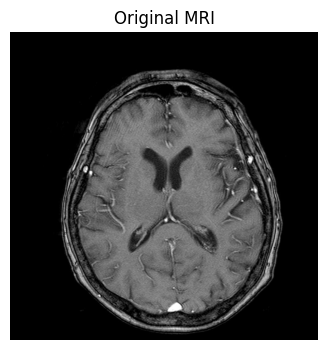

Shape: (800, 800) Range: (np.float64(0.0), np.float64(0.9999999999999961))


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 实验一、二数据
img = np.load(r"D:\coding\DIP_project\LAB3\lab3.npy").astype(np.float64)

# 如果是3D数据，取中间一张切片
if img.ndim == 3:
    img = img[img.shape[0] // 2]

# 归一化到[0,1]
img = (img - img.min()) / (img.max() - img.min() + 1e-12)

plt.figure(figsize=(4,4))
plt.imshow(img, cmap="gray")
plt.title("Original MRI")
plt.axis("off")
plt.show()

print("Shape:", img.shape, "Range:", (img.min(), img.max()))

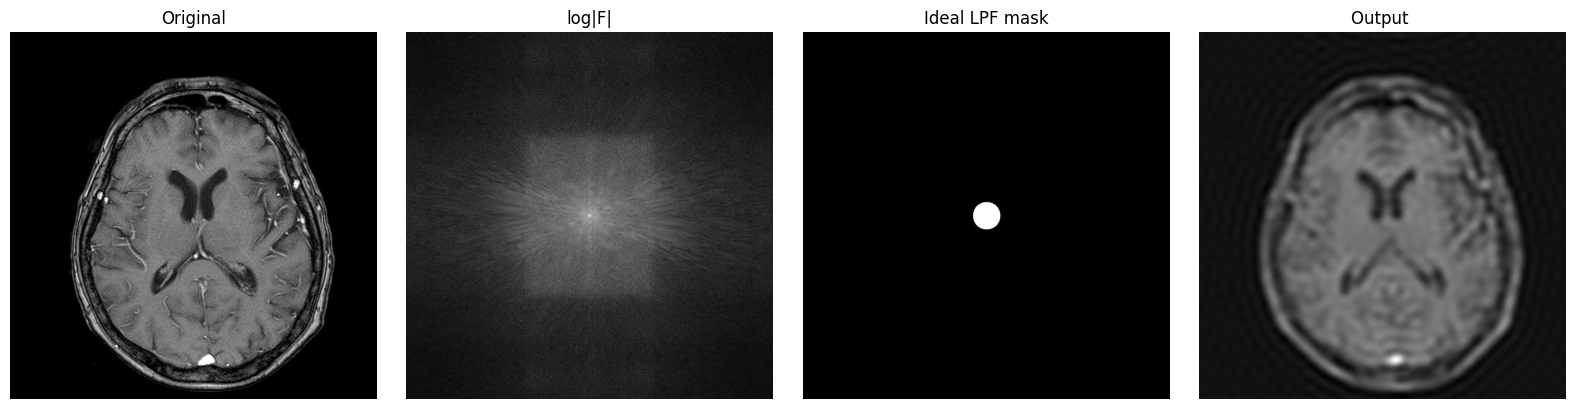

In [8]:
# Project 1 

def ideal_lpf_bug(shape, D0):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    cx, cy = h // 2, w // 2   
    D = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
    return (D <= D0).astype(np.float64)

D0 = 30
F = fft2c(img)
H_bug = ideal_lpf_bug(img.shape, D0)
out_bug = normalize01(ifft2c(F * H_bug))

show_images([img, np.log1p(np.abs(F)), H_bug, out_bug],
            ["Original", "log|F|", "Ideal LPF mask", "Output "],
            figsize=(16, 4))

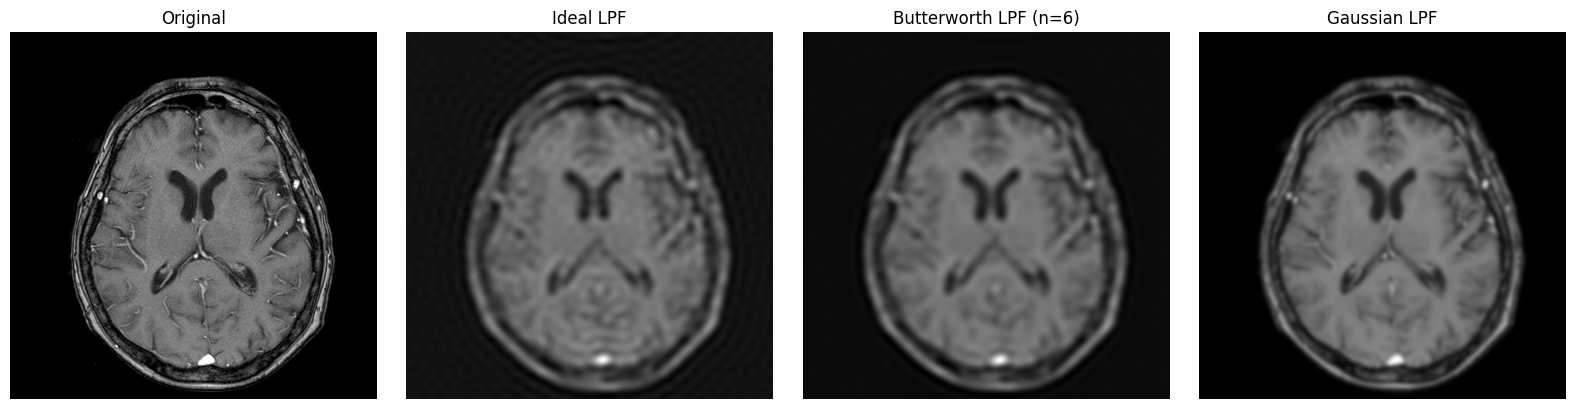

In [9]:
# Project 1 - 修复版：Ideal / Butterworth(n=6) / Gaussian 低通

def distance_grid(shape):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    cx, cy = w // 2, h // 2
    return np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)


def ideal_lpf(shape, D0):
    D = distance_grid(shape)
    return (D <= D0).astype(np.float64)


def butterworth_lpf(shape, D0, n=6):
    D = distance_grid(shape)
    return 1.0 / (1.0 + (D / (D0 + 1e-12)) ** (2 * n))


def gaussian_lpf(shape, D0):
    D = distance_grid(shape)
    return np.exp(-(D ** 2) / (2 * (D0 ** 2)))

D0 = 30
F = fft2c(img)
H_i = ideal_lpf(img.shape, D0)
H_b = butterworth_lpf(img.shape, D0, n=6)
H_g = gaussian_lpf(img.shape, D0)

out_i = normalize01(ifft2c(F * H_i))
out_b = normalize01(ifft2c(F * H_b))
out_g = normalize01(ifft2c(F * H_g))

show_images([img, out_i, out_b, out_g],
            ["Original", "Ideal LPF", "Butterworth LPF (n=6)", "Gaussian LPF"],
            figsize=(16, 4))

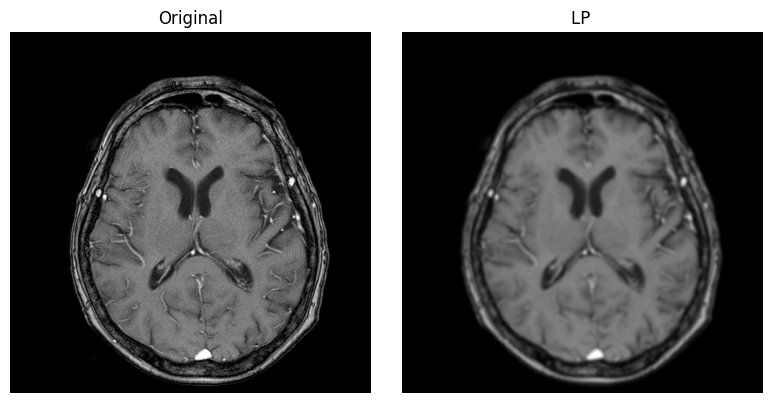

In [11]:
# Project 2 

def gaussian_kernel_bug(ksize, sigma):
    ax = np.arange(-(ksize // 2), ksize // 2 + 1)
    X, Y = np.meshgrid(ax, ax)
    K = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    return K  

if SCIPY_OK:
    K_bug = gaussian_kernel_bug(13, sigma=3)
    lp_bug = convolve2d(img, K_bug, mode='same', boundary='symm')
    show_images([img, normalize01(lp_bug)], ["Original", "LP "], figsize=(8,4))
else:
    print("跳过：当前环境无 scipy。")

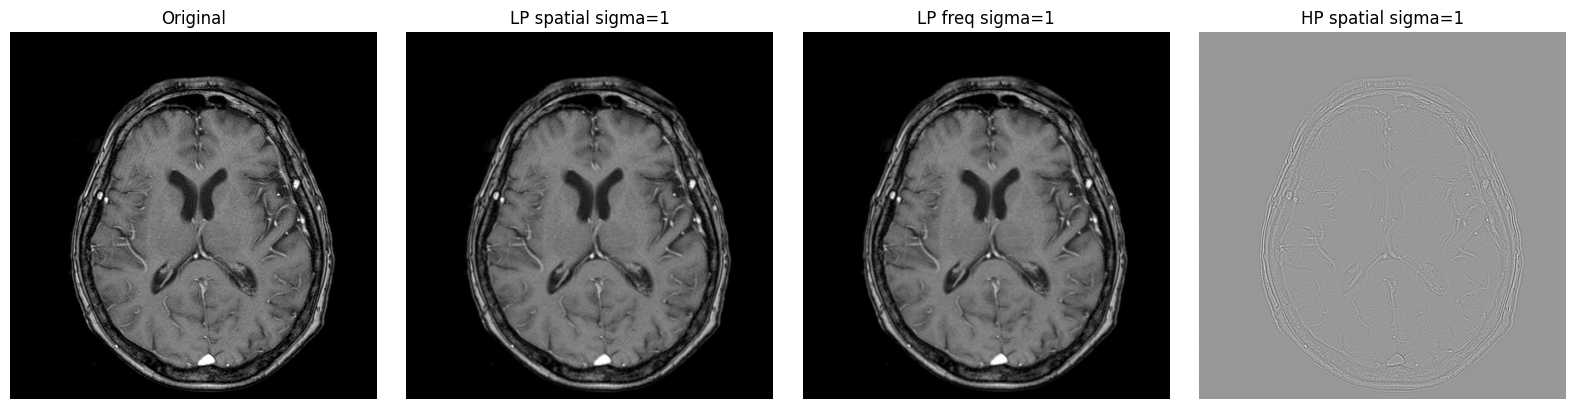

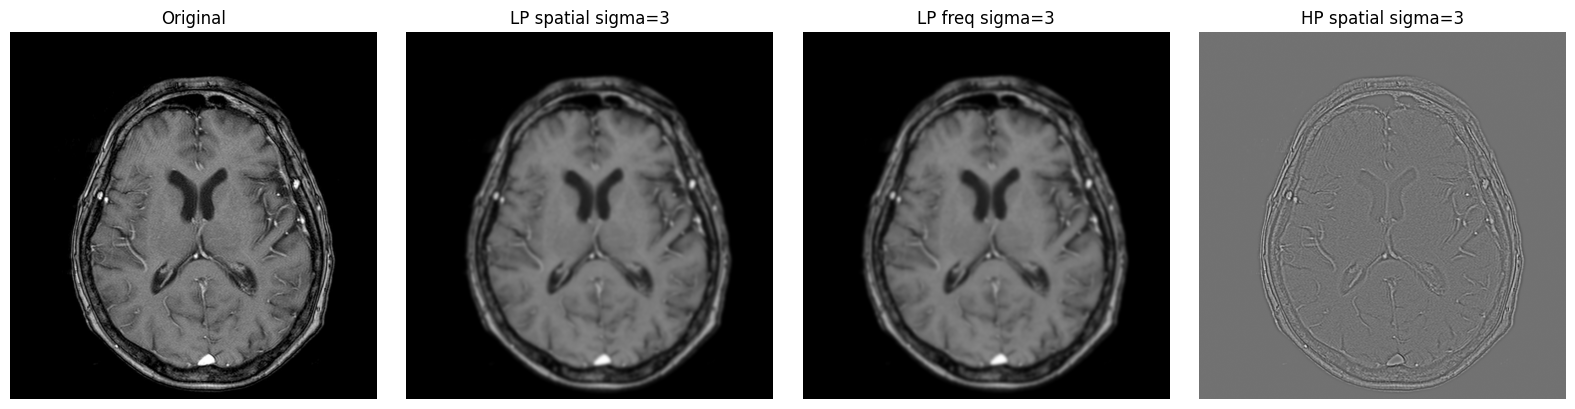

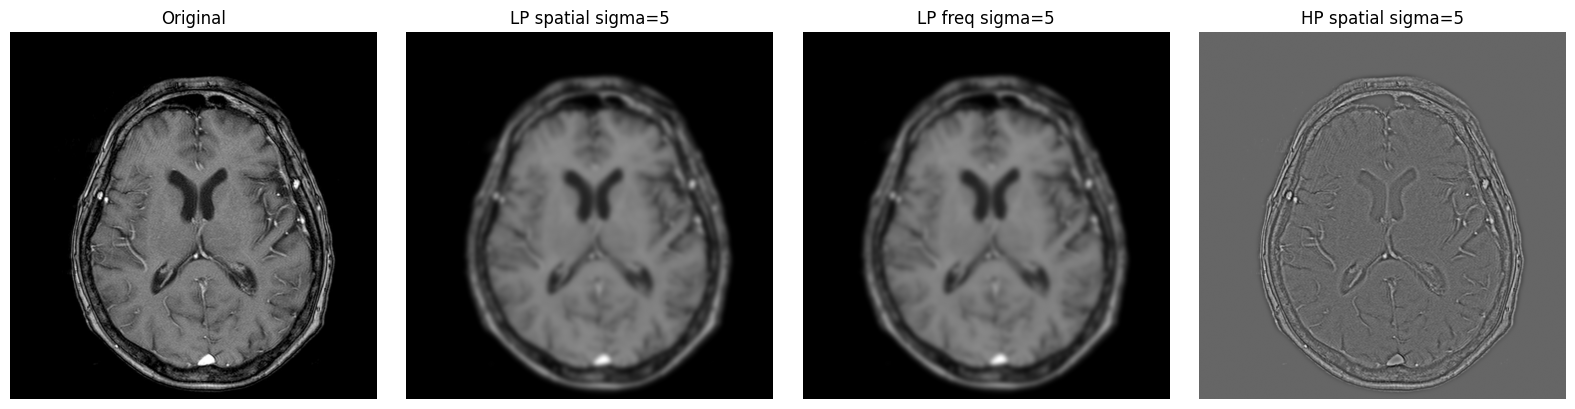

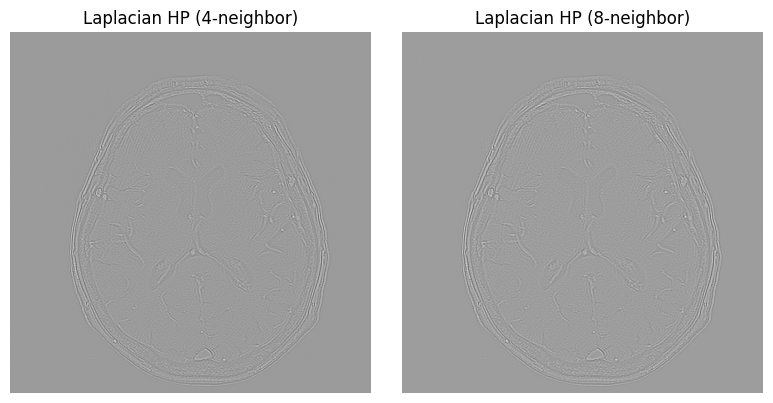

In [13]:
# Project 2 

def gaussian_kernel(ksize, sigma):
    ax = np.arange(-(ksize // 2), ksize // 2 + 1)
    X, Y = np.meshgrid(ax, ax)
    K = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    K /= K.sum() + 1e-12
    return K


def psf2otf(psf, shape):
    out = np.zeros(shape, dtype=np.float64)
    kh, kw = psf.shape
    out[:kh, :kw] = psf
    out = np.roll(out, -kh // 2, axis=0)
    out = np.roll(out, -kw // 2, axis=1)
    return np.fft.fft2(out)

if not SCIPY_OK:
    print("当前环境无 scipy，建议安装 scipy 后再运行本单元。")
else:
    sigma_list = [1, 3, 5]
    for s in sigma_list:
        ksize = int(2 * np.ceil(3 * s) + 1)
        K = gaussian_kernel(ksize, s)

        # 空间域低通
        lp_spatial = convolve2d(img, K, mode='same', boundary='symm')
        hp_spatial = img - lp_spatial

        # 频域对应（由空间核 FFT 得到）
        H = psf2otf(K, img.shape)
        F0 = np.fft.fft2(img)
        lp_freq = np.real(np.fft.ifft2(F0 * H))
        hp_freq = img - lp_freq

        show_images(
            [img, normalize01(lp_spatial), normalize01(lp_freq), normalize01(hp_spatial)],
            [f"Original", f"LP spatial sigma={s}", f"LP freq sigma={s}", f"HP spatial sigma={s}"],
            figsize=(16, 4)
        )

    # Laplacian 高通
    lap4 = np.array([[0, -1, 0],
                     [-1, 4, -1],
                     [0, -1, 0]], dtype=np.float64)

    lap8 = np.array([[-1, -1, -1],
                     [-1, 8, -1],
                     [-1, -1, -1]], dtype=np.float64)

    hp_lap4 = convolve2d(img, lap4, mode='same', boundary='symm')
    hp_lap8 = convolve2d(img, lap8, mode='same', boundary='symm')

    show_images([normalize01(hp_lap4), normalize01(hp_lap8)],
                ["Laplacian HP (4-neighbor)", "Laplacian HP (8-neighbor)"],
                figsize=(8,4))

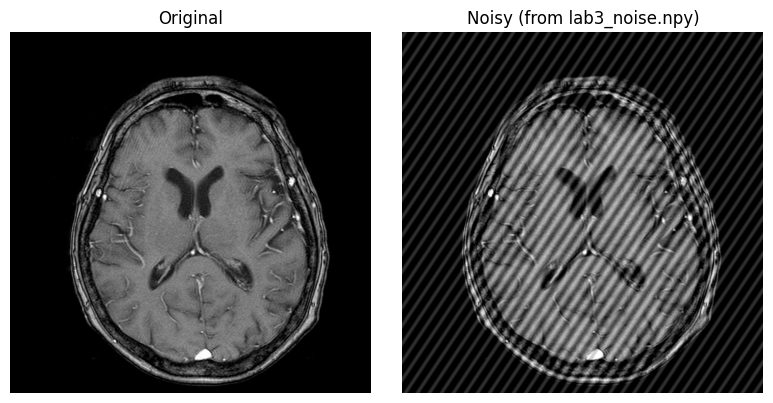

In [14]:
# Project 3 - 直接读取含噪图
noisy_img = np.load(r"D:\coding\DIP_project\LAB3\lab3_noise.npy").astype(np.float64)

# 如果是3D，取中间切片
if noisy_img.ndim == 3:
    noisy_img = noisy_img[noisy_img.shape[0] // 2]

# 归一化到[0,1]
noisy_img = (noisy_img - noisy_img.min()) / (noisy_img.max() - noisy_img.min() + 1e-12)

show_images([img, noisy_img], ["Original", "Noisy (from lab3_noise.npy)"], figsize=(8,4))

In [15]:
# Project 3 

def notch_reject_bug(shape, centers, r=5):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    H = np.ones(shape, dtype=np.float64)
    for (cy, cx) in centers:  # 只处理一个点，不处理对称点
        D = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
        H[D <= r] = 0
    return H

Fn = fft2c(noisy_img)
mag = np.log1p(np.abs(Fn))

# 这个中心需要根据频谱亮点微调
centers_bug = [(h // 2 + 20, w // 2 + 20)]
H_bug3 = notch_reject_bug(noisy_img.shape, centers_bug, r=5)
out_bug3 = normalize01(ifft2c(Fn * H_bug3))

show_images([mag, H_bug3, out_bug3], ["log|F_noisy|", "Notch mask ", "Denoised"], figsize=(12,4))

NameError: name 'h' is not defined

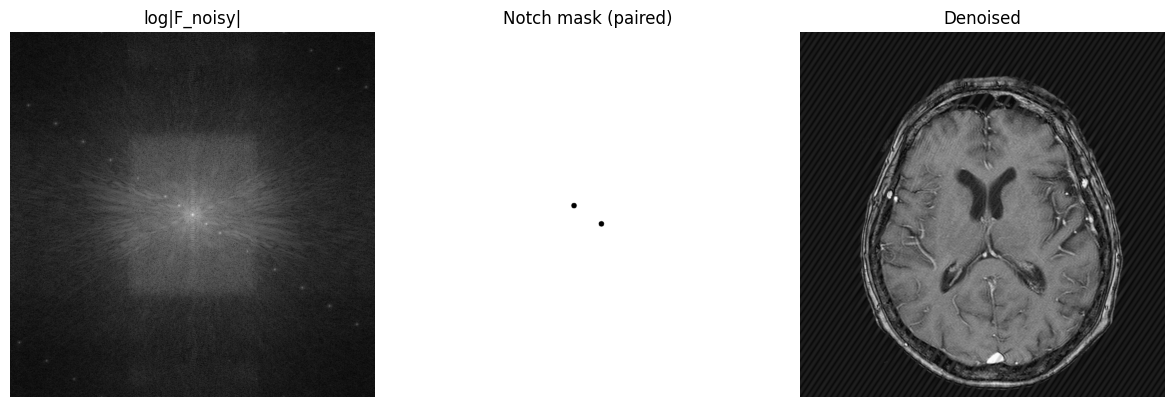

detected peak: (np.int64(380), np.int64(370)) paired: (np.int64(420), np.int64(430))


In [ ]:
# Project 3 
import numpy as np

def notch_reject(shape, center_pairs, r=6):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    H = np.ones(shape, dtype=np.float64)
    for (cy1, cx1), (cy2, cx2) in center_pairs:
        D1 = np.sqrt((X - cx1) ** 2 + (Y - cy1) ** 2)
        D2 = np.sqrt((X - cx2) ** 2 + (Y - cy2) ** 2)
        H[(D1 <= r) | (D2 <= r)] = 0
    return H

Fn = fft2c(noisy_img)
mag = np.log1p(np.abs(Fn))

h, w = noisy_img.shape
cy, cx = h // 2, w // 2

# 去掉中心低频区域，只在外围找最亮噪声峰
search = mag.copy()
rr = 18
search[cy-rr:cy+rr+1, cx-rr:cx+rr+1] = 0

# 找一个最亮峰
py, px = np.unravel_index(np.argmax(search), search.shape)

# 构造对称峰
qy, qx = 2 * cy - py, 2 * cx - px
center_pairs = [((py, px), (qy, qx))]

H = notch_reject(noisy_img.shape, center_pairs, r=6)
out = normalize01(ifft2c(Fn * H))

show_images(
    [mag, H, out],
    ["log|F_noisy|", "Notch mask (paired)", "Denoised"],
    figsize=(12, 4)
)

print("detected peak:", (py, px), "paired:", (qy, qx))

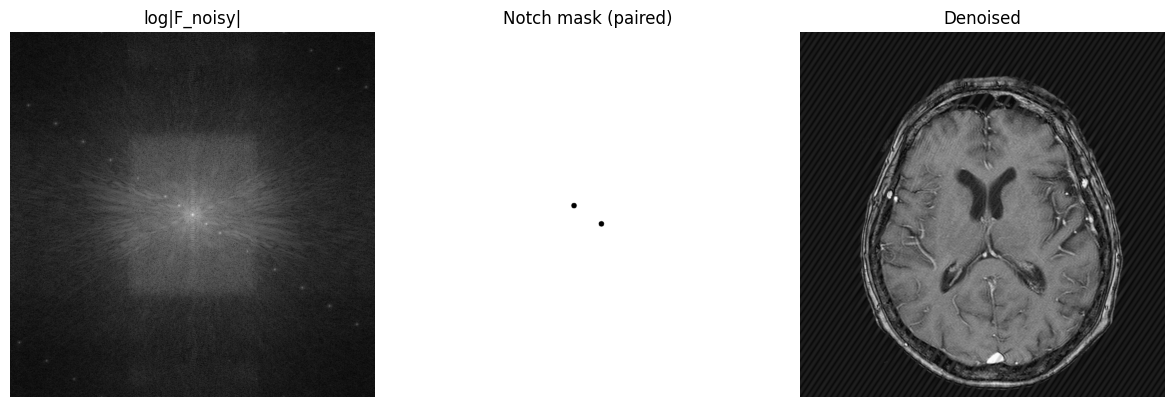

detected peak: (np.int64(380), np.int64(370)) paired: (np.int64(420), np.int64(430))


In [26]:
# Project 3 
import numpy as np

def notch_reject(shape, center_pairs, r=6):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    H = np.ones(shape, dtype=np.float64)
    for (cy1, cx1), (cy2, cx2) in center_pairs:
        D1 = np.sqrt((X - cx1) ** 2 + (Y - cy1) ** 2)
        D2 = np.sqrt((X - cx2) ** 2 + (Y - cy2) ** 2)
        H[(D1 <= r) | (D2 <= r)] = 0
    return H

Fn = fft2c(noisy_img)
mag = np.log1p(np.abs(Fn))

h, w = noisy_img.shape
cy, cx = h // 2, w // 2

# 去掉中心低频区域，只在外围找最亮噪声峰
search = mag.copy()
rr = 20
search[cy-rr:cy+rr+1, cx-rr:cx+rr+1] = 0

# 找一个最亮峰
py, px = np.unravel_index(np.argmax(search), search.shape)

# 构造对称峰
qy, qx = 2 * cy - py, 2 * cx - px
center_pairs = [((py, px), (qy, qx))]

H = notch_reject(noisy_img.shape, center_pairs, r=6)
out = normalize01(ifft2c(Fn * H))

show_images(
    [mag, H, out],
    ["log|F_noisy|", "Notch mask (paired)", "Denoised"],
    figsize=(12, 4)
)

print("detected peak:", (py, px), "paired:", (qy, qx))

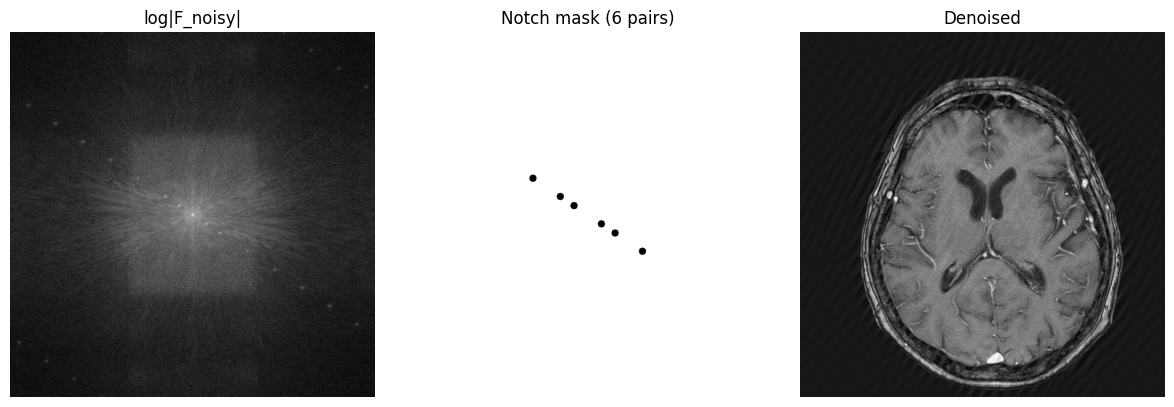

peaks: [(np.int64(380), np.int64(370)), (np.int64(420), np.int64(430)), (np.int64(360), np.int64(340)), (np.int64(440), np.int64(460)), (np.int64(480), np.int64(520)), (np.int64(320), np.int64(280))]
pairs: [((np.int64(380), np.int64(370)), (np.int64(420), np.int64(430))), ((np.int64(420), np.int64(430)), (np.int64(380), np.int64(370))), ((np.int64(360), np.int64(340)), (np.int64(440), np.int64(460))), ((np.int64(440), np.int64(460)), (np.int64(360), np.int64(340))), ((np.int64(480), np.int64(520)), (np.int64(320), np.int64(280))), ((np.int64(320), np.int64(280)), (np.int64(480), np.int64(520)))]


In [41]:
# Project 3 (debug instrumentation)
import numpy as np
import json
import time

DEBUG_LOG_PATH = r"D:\coding\DIP_project\debug-7dd8f0.log"


def _to_builtin(v):
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    if isinstance(v, np.ndarray):
        return v.tolist()
    if isinstance(v, (list, tuple)):
        return [_to_builtin(x) for x in v]
    if isinstance(v, dict):
        return {k: _to_builtin(x) for k, x in v.items()}
    return v


def debug_log(run_id, hypothesis_id, location, message, data):
    payload = {
        "sessionId": "7dd8f0",
        "runId": run_id,
        "hypothesisId": hypothesis_id,
        "location": location,
        "message": message,
        "data": _to_builtin(data),
        "timestamp": int(time.time() * 1000),
    }
    with open(DEBUG_LOG_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps(payload, ensure_ascii=False) + "\n")


def notch_reject(shape, center_pairs, r=6):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    H = np.ones(shape, dtype=np.float64)
    for (cy1, cx1), (cy2, cx2) in center_pairs:
        D1 = np.sqrt((X - cx1) ** 2 + (Y - cy1) ** 2)
        D2 = np.sqrt((X - cx2) ** 2 + (Y - cy2) ** 2)
        H[(D1 <= r) | (D2 <= r)] = 0
    return H


run_id = "run1"
Fn = fft2c(noisy_img)
mag = np.log1p(np.abs(Fn))

h, w = noisy_img.shape
cy, cx = h // 2, w // 2

# 1) 屏蔽中心低频
search = mag.copy()
rr = 25
search[cy-rr:cy+rr+1, cx-rr:cx+rr+1] = 0

# 2) 找 K 个峰（每找到一个就抹掉附近，避免重复）
K = 6
suppress = 10
peaks = []
peak_values = []

for _ in range(K):
    py, px = np.unravel_index(np.argmax(search), search.shape)
    peaks.append((py, px))
    peak_values.append(float(mag[py, px]))

    Y, X = np.ogrid[:h, :w]
    D = np.sqrt((X - px) ** 2 + (Y - py) ** 2)
    search[D <= suppress] = 0

# 3) 构造对称峰对
center_pairs = []
for py, px in peaks:
    qy, qx = 2 * cy - py, 2 * cx - px
    center_pairs.append(((py, px), (qy, qx)))

# 4) 构造多对 notch mask 并滤波
r = 8
H = notch_reject(noisy_img.shape, center_pairs, r=r)
out = normalize01(ifft2c(Fn * H))

# region agent log
debug_log(run_id, "H1", "LAB3_3230100700_debug.ipynb:project3", "params", {
    "shape": [h, w], "rr": rr, "K": K, "suppress": suppress, "r": r
})
# endregion

# region agent log
debug_log(run_id, "H2", "LAB3_3230100700_debug.ipynb:project3", "selected_peaks", {
    "peaks": peaks, "peak_values": peak_values
})
# endregion

# region agent log
debug_log(run_id, "H3", "LAB3_3230100700_debug.ipynb:project3", "center_pairs", {
    "center": [cy, cx], "pairs": center_pairs
})
# endregion

residual_mag = np.log1p(np.abs(fft2c(out)))
residual_max = float(np.max(residual_mag[cy-rr:cy+rr+1, cx-rr:cx+rr+1]))
outer_mask = np.ones_like(residual_mag, dtype=bool)
outer_mask[cy-rr:cy+rr+1, cx-rr:cx+rr+1] = False
residual_outer_max = float(np.max(residual_mag[outer_mask]))

# region agent log
debug_log(run_id, "H4", "LAB3_3230100700_debug.ipynb:project3", "residual_spectrum", {
    "residual_center_max": residual_max,
    "residual_outer_max": residual_outer_max
})
# endregion

show_images(
    [mag, H, out],
    ["log|F_noisy|", f"Notch mask ({K} pairs)", "Denoised"],
    figsize=(12, 4)
)

print("peaks:", peaks)
print("pairs:", center_pairs)

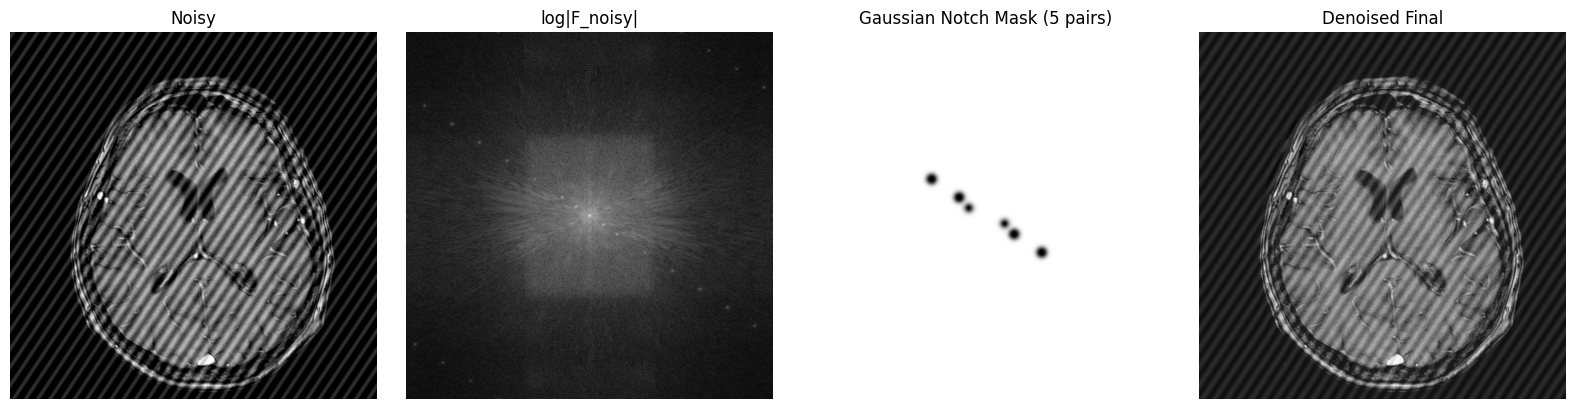

In [45]:
# Project 3 
# 思路：自动找多对噪声峰 + 共轭对称 + Gaussian 平滑陷波（减少残留和伪影）
import numpy as np


def detect_peak_pairs(mag, K=4, rr=35, suppress=14):
    """在 log 频谱中自动寻找 K 个噪声峰，并构造对称峰对。"""
    h, w = mag.shape
    cy, cx = h // 2, w // 2

    search = mag.copy()
    search[cy-rr:cy+rr+1, cx-rr:cx+rr+1] = 0  # 屏蔽中心低频

    peaks = []
    Y, X = np.ogrid[:h, :w]
    for _ in range(K):
        py, px = np.unravel_index(np.argmax(search), search.shape)
        peaks.append((py, px))

        # 抑制邻域，避免重复选中同一团峰
        D = np.sqrt((X - px) ** 2 + (Y - py) ** 2)
        search[D <= suppress] = 0

    pairs = []
    for py, px in peaks:
        qy, qx = 2 * cy - py, 2 * cx - px
        pairs.append(((py, px), (qy, qx)))
    return pairs, peaks


def gaussian_notch_reject(shape, center_pairs, sigma=7.0):
    """Gaussian 陷波：乘积形式，过渡平滑。"""
    h, w = shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]

    H = np.ones(shape, dtype=np.float64)
    for (y1, x1), (y2, x2) in center_pairs:
        D1 = np.sqrt((X - x1) ** 2 + (Y - y1) ** 2)
        D2 = np.sqrt((X - x2) ** 2 + (Y - y2) ** 2)

        # 单对 notch reject（在对应频率点附近抑制）
        notch_pair = (1.0 - np.exp(-(D1 ** 2) / (2 * sigma ** 2))) * \
                     (1.0 - np.exp(-(D2 ** 2) / (2 * sigma ** 2)))
        H *= notch_pair

    # 防止数值太小
    H = np.clip(H, 0.0, 1.0)
    return H


# ====== 运行 ======
Fn = fft2c(noisy_img)
mag = np.log1p(np.abs(Fn))

# 这组参数通常比硬阈值 mask 更稳，可按需微调
K = 5
rr = 35
suppress = 14
sigma = 7.0

center_pairs, peaks = detect_peak_pairs(mag, K=K, rr=rr, suppress=suppress)
H_final = gaussian_notch_reject(noisy_img.shape, center_pairs, sigma=sigma)
out_final = normalize01(ifft2c(Fn * H_final))

show_images(
    [noisy_img, mag, H_final, out_final],
    ["Noisy", "log|F_noisy|", f"Gaussian Notch Mask ({K} pairs)", "Denoised Final"],
    figsize=(16, 4)
)


In [ ]:
# Project 3 - Final stable version (manual peak picking)
# 用法：运行后在频谱图上点击 2~6 个“亮噪声峰”（不要点中心），回车结束。

import numpy as np
import matplotlib.pyplot as plt


def notch_reject_manual(shape, centers, r=7):
    h, w = shape
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    H = np.ones(shape, dtype=np.float64)

    for (py, px) in centers:
        # 原峰
        D1 = np.sqrt((X - px) ** 2 + (Y - py) ** 2)
        H[D1 <= r] = 0

        # 对称峰
        qy, qx = 2 * cy - py, 2 * cx - px
        D2 = np.sqrt((X - qx) ** 2 + (Y - qy) ** 2)
        H[D2 <= r] = 0

    return H


Fn = fft2c(noisy_img)
mag = np.log1p(np.abs(Fn))

# 1) 手动点选噪声峰
plt.figure(figsize=(6, 6))
plt.imshow(mag, cmap='gray')
plt.title('Click noise peaks (2~6 points), then press Enter')
plt.axis('off')
pts = plt.ginput(n=-1, timeout=0)
plt.close()

centers = [(int(round(y)), int(round(x))) for (x, y) in pts]
print('picked centers:', centers)

# 2) 构造 notch mask 并滤波
r = 7  # 条纹残留就增大到 8~10；细节损失就减小到 5~6
H_manual = notch_reject_manual(noisy_img.shape, centers, r=r)
out_manual = normalize01(ifft2c(Fn * H_manual))

show_images(
    [noisy_img, mag, H_manual, out_manual],
    ['Noisy', 'log|F_noisy|', f'Manual Notch Mask (r={r})', 'Denoised (manual)'],
    figsize=(16, 4)
)

print('Tip: 若仍有斜纹，再补点 1~2 个亮峰；优先调 r=6~9。')

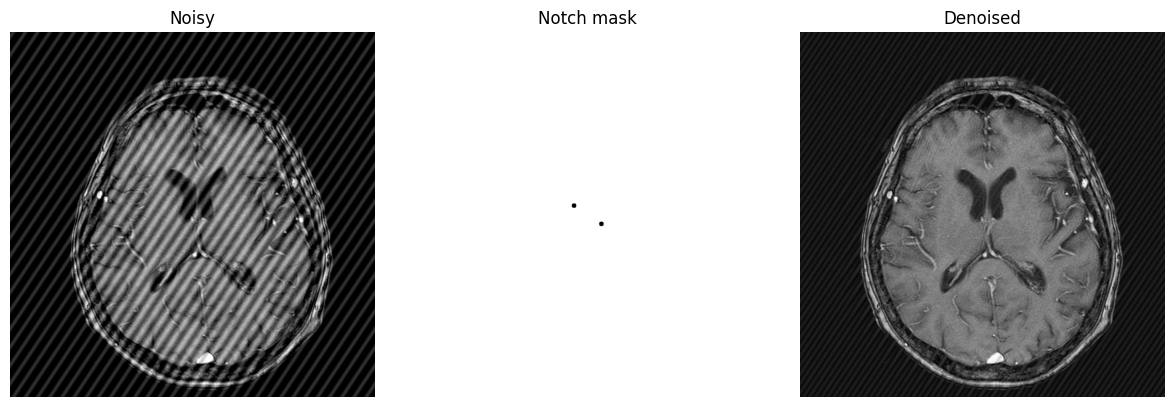

In [19]:
# Project 3 

def notch_reject(shape, center_pairs, r=5):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    H = np.ones(shape, dtype=np.float64)
    for (cy1, cx1), (cy2, cx2) in center_pairs:
        D1 = np.sqrt((X - cx1) ** 2 + (Y - cy1) ** 2)
        D2 = np.sqrt((X - cx2) ** 2 + (Y - cy2) ** 2)
        H[(D1 <= r) | (D2 <= r)] = 0
    return H

c1 = (py, px)
c2 = (qy, qx)
H3 = notch_reject(noisy_img.shape, [(c1, c2)], r=5)

out3 = normalize01(ifft2c(fft2c(noisy_img) * H3))
show_images([noisy_img, H3, out3], ["Noisy", "Notch mask", "Denoised"], figsize=(12,4))